In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(
    r"D:\ML_PROJECT\Sample - Superstore.csv",
    encoding="latin1"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 9994
Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate Rows: 0

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City         

In [4]:
# Convert date columns to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Check the result
print("Order Date type:", df["Order Date"].dtype)
print("Ship Date type:", df["Ship Date"].dtype)

print("\nDate range:")
print("First Order Date:", df["Order Date"].min())
print("Last Order Date:", df["Order Date"].max())

Order Date type: datetime64[ns]
Ship Date type: datetime64[ns]

Date range:
First Order Date: 2014-01-03 00:00:00
Last Order Date: 2017-12-30 00:00:00


In [5]:
# Create monthly sales data
monthly_sales = (
    df.set_index("Order Date")
      .resample("MS")["Sales"]
      .sum()
      .reset_index()
)

# Display the result
print("Monthly sales shape:", monthly_sales.shape)
print("\nFirst 5 months:")
print(monthly_sales.head())

print("\nLast 5 months:")
print(monthly_sales.tail())

Monthly sales shape: (48, 2)

First 5 months:
  Order Date      Sales
0 2014-01-01  14236.895
1 2014-02-01   4519.892
2 2014-03-01  55691.009
3 2014-04-01  28295.345
4 2014-05-01  23648.287

Last 5 months:
   Order Date        Sales
43 2017-08-01   63120.8880
44 2017-09-01   87866.6520
45 2017-10-01   77776.9232
46 2017-11-01  118447.8250
47 2017-12-01   83829.3188


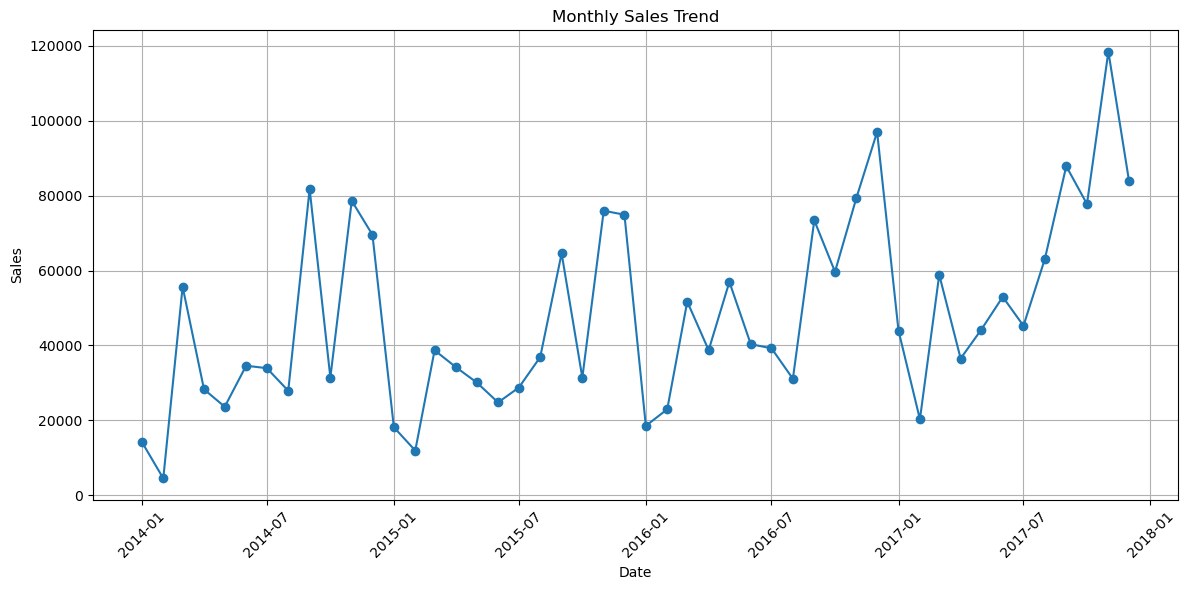

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [7]:
# Create time-based features
monthly_sales["Year"] = monthly_sales["Order Date"].dt.year
monthly_sales["Month"] = monthly_sales["Order Date"].dt.month
monthly_sales["Time_Index"] = np.arange(len(monthly_sales))

# Check the new features
print(monthly_sales.head())

  Order Date      Sales  Year  Month  Time_Index
0 2014-01-01  14236.895  2014      1           0
1 2014-02-01   4519.892  2014      2           1
2 2014-03-01  55691.009  2014      3           2
3 2014-04-01  28295.345  2014      4           3
4 2014-05-01  23648.287  2014      5           4


In [8]:
# Split data chronologically
train_size = int(len(monthly_sales) * 0.8)

train = monthly_sales.iloc[:train_size].copy()
test = monthly_sales.iloc[train_size:].copy()

print("Training data:", len(train), "months")
print("Testing data:", len(test), "months")

print("\nTraining period:")
print(train["Order Date"].min(), "to", train["Order Date"].max())

print("\nTesting period:")
print(test["Order Date"].min(), "to", test["Order Date"].max())

Training data: 38 months
Testing data: 10 months

Training period:
2014-01-01 00:00:00 to 2017-02-01 00:00:00

Testing period:
2017-03-01 00:00:00 to 2017-12-01 00:00:00


In [9]:
# Prepare features and target

X_train = train[["Time_Index", "Month"]]
y_train = train["Sales"]

X_test = test[["Time_Index", "Month"]]
y_test = test["Sales"]

# Create and train the model
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [10]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[37577.3681398  42433.54956466 47289.73098951 52145.91241437
 57002.09383922 61858.27526408 66714.45668893 71570.63811379
 76426.81953864 81283.0009635 ]


In [11]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Model Evaluation")
print("-----------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")

Model Evaluation
-----------------
MAE  : 11599.75
MSE  : 289584865.02
RMSE : 17017.19


In [12]:
# Compare actual and predicted sales

comparison = pd.DataFrame({
    "Date": test["Order Date"],
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison["Error"] = comparison["Actual Sales"] - comparison["Predicted Sales"]

print(comparison)

         Date  Actual Sales  Predicted Sales         Error
38 2017-03-01    58872.3528     37577.368140  21294.984660
39 2017-04-01    36521.5361     42433.549565  -5912.013465
40 2017-05-01    44261.1102     47289.730990  -3028.620790
41 2017-06-01    52981.7257     52145.912414    835.813286
42 2017-07-01    45264.4160     57002.093839 -11737.677839
43 2017-08-01    63120.8880     61858.275264   1262.612736
44 2017-09-01    87866.6520     66714.456689  21152.195311
45 2017-10-01    77776.9232     71570.638114   6206.285086
46 2017-11-01   118447.8250     76426.819539  42021.005461
47 2017-12-01    83829.3188     81283.000963   2546.317837


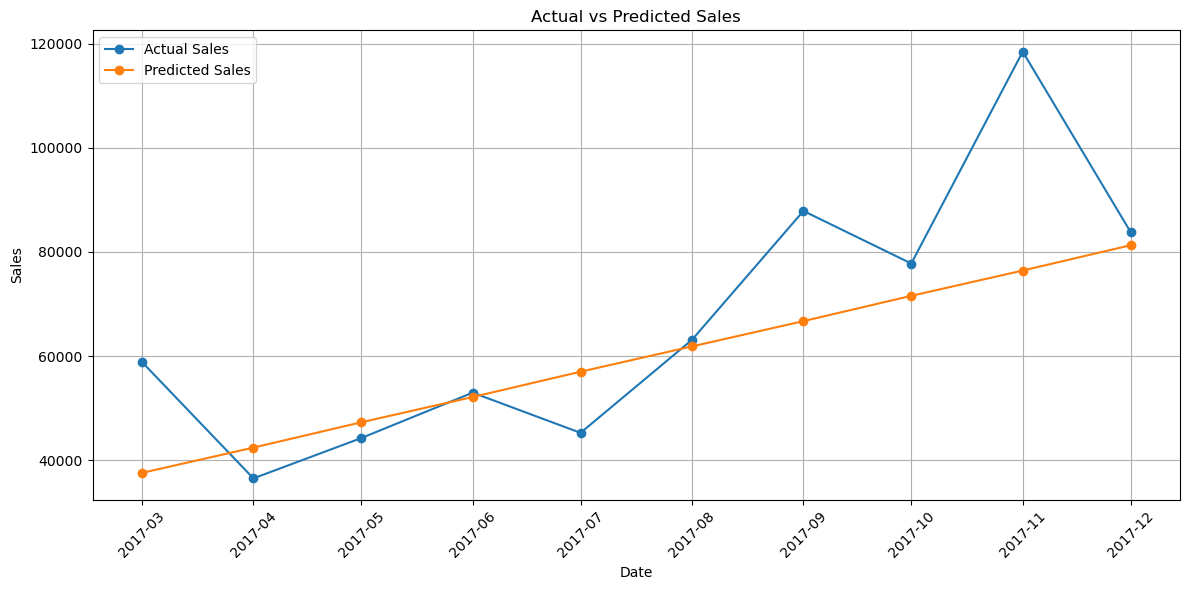

In [13]:
# Plot actual vs predicted sales

plt.figure(figsize=(12, 6))

plt.plot(
    comparison["Date"],
    comparison["Actual Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    comparison["Date"],
    comparison["Predicted Sales"],
    marker="o",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [14]:
# Error analysis

comparison["Absolute Error"] = comparison["Error"].abs()
comparison["Percentage Error (%)"] = (
    comparison["Absolute Error"] / comparison["Actual Sales"]
) * 100

print("Error Analysis")
print("----------------")
print(comparison)

Error Analysis
----------------
         Date  Actual Sales  Predicted Sales         Error  Absolute Error  \
38 2017-03-01    58872.3528     37577.368140  21294.984660    21294.984660   
39 2017-04-01    36521.5361     42433.549565  -5912.013465     5912.013465   
40 2017-05-01    44261.1102     47289.730990  -3028.620790     3028.620790   
41 2017-06-01    52981.7257     52145.912414    835.813286      835.813286   
42 2017-07-01    45264.4160     57002.093839 -11737.677839    11737.677839   
43 2017-08-01    63120.8880     61858.275264   1262.612736     1262.612736   
44 2017-09-01    87866.6520     66714.456689  21152.195311    21152.195311   
45 2017-10-01    77776.9232     71570.638114   6206.285086     6206.285086   
46 2017-11-01   118447.8250     76426.819539  42021.005461    42021.005461   
47 2017-12-01    83829.3188     81283.000963   2546.317837     2546.317837   

    Percentage Error (%)  
38             36.171452  
39             16.187746  
40              6.842623  
4

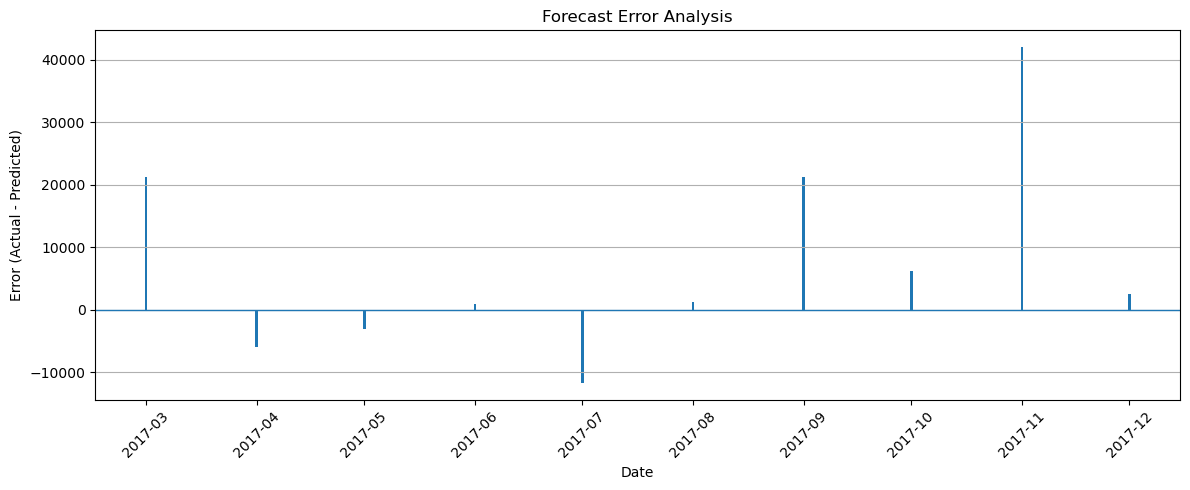

In [15]:
# Plot forecast errors

plt.figure(figsize=(12, 5))

plt.bar(
    comparison["Date"],
    comparison["Error"]
)

plt.axhline(0, linewidth=1)

plt.title("Forecast Error Analysis")
plt.xlabel("Date")
plt.ylabel("Error (Actual - Predicted)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.tight_layout()

plt.show()

In [16]:
# Forecast the next 6 months

future_periods = 6

last_index = monthly_sales["Time_Index"].iloc[-1]

future_index = np.arange(
    last_index + 1,
    last_index + future_periods + 1
)

future_dates = pd.date_range(
    start=monthly_sales["Order Date"].iloc[-1] + pd.DateOffset(months=1),
    periods=future_periods,
    freq="MS"
)

future_months = future_dates.month

future_X = pd.DataFrame({
    "Time_Index": future_index,
    "Month": future_months
})

future_sales = model.predict(future_X)

forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Sales": future_sales
})

print("Next 6 Months Sales Forecast")
print(forecast)

Next 6 Months Sales Forecast
        Date  Forecasted Sales
0 2018-01-01      33378.785736
1 2018-02-01      38234.967160
2 2018-03-01      43091.148585
3 2018-04-01      47947.330010
4 2018-05-01      52803.511435
5 2018-06-01      57659.692860


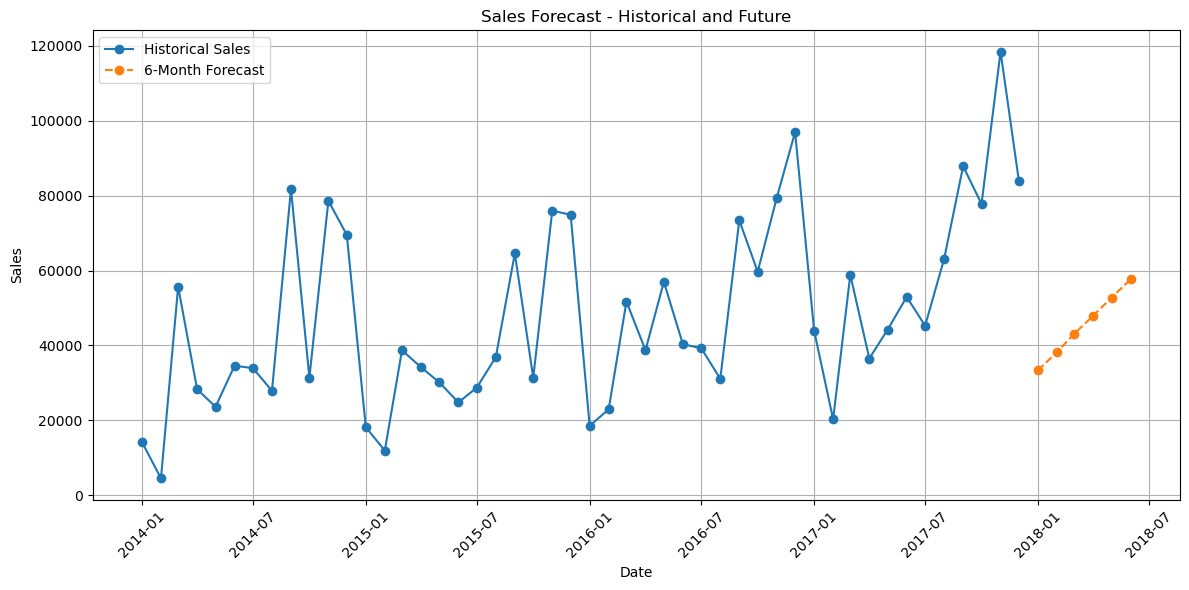

In [17]:
# Final Sales Forecast Visualization

plt.figure(figsize=(12, 6))

# Historical sales
plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    label="Historical Sales"
)

# Future forecast
plt.plot(
    forecast["Date"],
    forecast["Forecasted Sales"],
    marker="o",
    linestyle="--",
    label="6-Month Forecast"
)

plt.title("Sales Forecast - Historical and Future")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
# Business Insights

print("BUSINESS INSIGHTS")
print("=" * 50)

print(f"1. Historical period: {monthly_sales['Order Date'].min().strftime('%B %Y')} "
      f"to {monthly_sales['Order Date'].max().strftime('%B %Y')}.")

print(f"2. Total historical sales: ${monthly_sales['Sales'].sum():,.2f}")

print(f"3. Average monthly sales: ${monthly_sales['Sales'].mean():,.2f}")

best_month = monthly_sales.loc[monthly_sales["Sales"].idxmax()]

print(f"4. Highest monthly sales: ${best_month['Sales']:,.2f} "
      f"in {best_month['Order Date'].strftime('%B %Y')}.")

print(f"5. Forecasted average sales for the next 6 months: "
      f"${forecast['Forecasted Sales'].mean():,.2f}")

print(f"6. Model MAE: ${mae:,.2f}")

print(f"7. Model RMSE: ${rmse:,.2f}")

print("8. The forecasting model can provide a baseline estimate "
      "of future monthly sales to support inventory and demand planning.")

BUSINESS INSIGHTS
1. Historical period: January 2014 to December 2017.
2. Total historical sales: $2,297,200.86
3. Average monthly sales: $47,858.35
4. Highest monthly sales: $118,447.82 in November 2017.
5. Forecasted average sales for the next 6 months: $45,519.24
6. Model MAE: $11,599.75
7. Model RMSE: $17,017.19
8. The forecasting model can provide a baseline estimate of future monthly sales to support inventory and demand planning.
